In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [6]:
data = load_breast_cancer()

X = data.data
y = data.target

X = pd.DataFrame(X, columns=data.feature_names)
y = pd.DataFrame(y, columns=['target'])

data = pd.concat([X, y], axis=1)
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [57]:
# for feature in X.columns:
#     for targ in y['target'].unique():
#         plot_df = data[data['target'] == targ]
#         plt.hist(plot_df[feature], bins=20, alpha=0.3, label=targ)
#         plt.legend()
#         plt.title(feature)
#     plt.show()

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(random_state=0)

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1.0, 10],
        'solver': ['liblinear'],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1.0, 10],
        'solver': ['liblinear'],
        'class_weight': ['balanced']
    }
]

grid = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

clf = grid.best_estimator_
print(clf)

y_preds = clf.predict(X_test)

coefs = pd.Series(clf.coef_[0], index=X.columns)
print(coefs)

score = accuracy_score(y_test, y_preds)
print(score)

OSError: [WinError 1450] Insufficient system resources exist to complete the requested service

0.4555555555555556


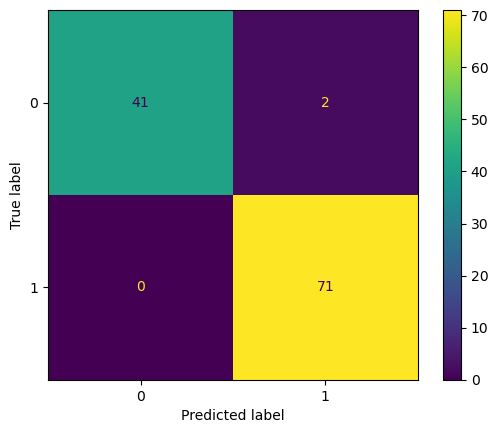

In [ ]:
y_probs = clf.predict_proba(X_test)[:,1]
melhor_t = 0.5
pred = (y_probs > melhor_t).astype(int)
_, _, melhor_fn, _ = confusion_matrix(y_test, pred).ravel()

for t in np.linspace(0.1, 0.9, 100):
  pred = (y_probs > t).astype(int)
  tp, fp, fn, tn = confusion_matrix(y_test, pred).ravel()
  if fn < melhor_fn or (t > melhor_t and fn == melhor_fn):
    melhor_t = t
    melhor_fn = fn
    conf = confusion_matrix(y_test, pred)

print(melhor_t)
ConfusionMatrixDisplay(conf).plot()
plt.show()